In [1]:
import os
import sys
from pathlib import Path

import importlib.util
repo_root = Path(importlib.util.find_spec("braincell").origin).resolve().parents[1]
if str(repo_root) in sys.path:
    sys.path.remove(str(repo_root))
sys.path.insert(0, str(repo_root))

os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import brainstate
import brainunit as u
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import braincell
from braincell import Branch, Cell, Morphology
from braincell.filter import BranchSlice, at
from braincell.mech import Ion, MechanismProbe
from braincell.ion import ToyCaBindingKinetic_SU2015_DCN

print('braincell version:', braincell.__version__)
print('braincell import path:', Path(braincell.__file__).resolve())

brainstate.environ.set(precision=64)


braincell version: 0.1.0
braincell import path: /home/swl/braincell-ion_dyn/braincell/__init__.py


In [2]:
from validation.neuron._paths import DATA_ROOT
mod_dir = Path(braincell.__file__).resolve().parent.parent / 'data' / 'cerebellum' / 'dcn_su2015'
mod_file = DATA_ROOT / 'mechanisms' / 'testing' / 'ToyCaBindingKinetic_SU15_DCN.mod'
print('mod dir:', mod_dir)
print('mod file exists:', mod_file.exists())


mod dir: /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/DCN
mod file exists: True


In [3]:
dt_ms = 0.05
duration_ms = 40.0
steps = int(duration_ms / dt_ms)
times_ms = np.arange(steps + 1) * dt_ms

temperature_celsius = 36.0
kf_per_mM_ms = 2.0
kb_per_ms = 0.5
btot_mM = 1.0
ci0_mM = 0.2
bc0_mM = 0.3
b0_mM = btot_mM - bc0_mM

print({'dt_ms': dt_ms, 'duration_ms': duration_ms, 'kf': kf_per_mM_ms, 'kb': kb_per_ms, 'Btot': btot_mM, 'Ci0': ci0_mM, 'BC0': bc0_mM, 'B0': b0_mM})


{'dt_ms': 0.05, 'duration_ms': 40.0, 'kf': 2.0, 'kb': 0.5, 'Btot': 1.0, 'Ci0': 0.2, 'BC0': 0.3, 'B0': 0.7}


In [4]:
from validation.neuron._mechanisms import compile_mechanisms
from validation.neuron._paths import DATA_ROOT
compiled_mod_dir = compile_mechanisms("dcn_su2015", files=[mod_file])
from neuron import h, load_mechanisms

if not load_mechanisms(str(compiled_mod_dir.resolve())):
    raise RuntimeError(f'NEURON mechanisms not found under {mod_dir!s}; compile the DCN mods first.')
h.load_file('stdrun.hoc')

sec = h.Section(name='soma')
sec.L = 20.0
sec.diam = 20.0
sec.nseg = 1
seg = sec(0.5)
sec.insert('ToyCaBindingKinetic_SU15_DCN')
mech = seg.ToyCaBindingKinetic_SU15_DCN

mech.kf = kf_per_mM_ms
mech.kb = kb_per_ms
mech.Btot = btot_mM

h.dt = dt_ms
h.tstop = duration_ms
h.v_init = -60.0

t_vec = h.Vector().record(h._ref_t)
cai_vec = h.Vector().record(seg._ref_cai)
bc_vec = h.Vector().record(mech._ref_bc)
b_vec = h.Vector().record(mech._ref_b)

h.finitialize(h.v_init)
seg.cai = ci0_mM
mech.bc = bc0_mM
mech.b = b0_mM
h.frecord_init()
h.continuerun(h.tstop)

neuron_t_ms = np.asarray(t_vec)
neuron_cai_mM = np.asarray(cai_vec)
neuron_bc_mM = np.asarray(bc_vec)
neuron_b_mM = np.asarray(b_vec)
neuron_total_mM = neuron_b_mM + neuron_bc_mM

print('NEURON start/end cai:', float(neuron_cai_mM[0]), float(neuron_cai_mM[-1]))
print('NEURON start/end bc:', float(neuron_bc_mM[0]), float(neuron_bc_mM[-1]))
print('NEURON max conserve drift:', float(np.max(np.abs(neuron_total_mM - btot_mM))))


NEURON start/end cai: 0.2 0.1403882032022078
NEURON start/end bc: 0.3 0.3596117967977924
NEURON max conserve drift: 1.1102230246251565e-16


--No graphics will be displayed.


In [5]:
dt = dt_ms * u.ms
ion = ToyCaBindingKinetic_SU2015_DCN(
    size=1,
    temp=u.celsius2kelvin(temperature_celsius),
    kf=kf_per_mM_ms / (u.mM * u.ms),
    kb=kb_per_ms / u.ms,
    Btot=btot_mM * u.mM,
    Ci_initializer=ci0_mM * u.mM,
    BC_initializer=bc0_mM * u.mM,
    solver='euler',
    substeps=1,
)
V = jnp.array([-60.0]) * u.mV
ion.init_state(V)

bc_cai = [float(np.asarray(ion.Ci.value.to_decimal(u.mM)).reshape(-1)[0])]
bc_bc = [float(np.asarray(ion.BC.value.to_decimal(u.mM)).reshape(-1)[0])]
bc_b = [float(np.asarray(np.asarray(ion.B.value.to_decimal(u.mM))).reshape(-1)[0])]

for _ in range(steps):
    ion.compute_derivative(V)
    ion.Ci.value = ion.Ci.value + ion.Ci.derivative * dt
    ion.BC.value = ion.BC.value + ion.BC.derivative * dt
    ion.post_integral(V)
    bc_cai.append(float(np.asarray(ion.Ci.value.to_decimal(u.mM)).reshape(-1)[0]))
    bc_bc.append(float(np.asarray(ion.BC.value.to_decimal(u.mM)).reshape(-1)[0]))
    bc_b.append(float(np.asarray(ion.B.value.to_decimal(u.mM)).reshape(-1)[0]))

bc_cai_mM = np.asarray(bc_cai)
bc_bc_mM = np.asarray(bc_bc)
bc_b_mM = np.asarray(bc_b)
bc_total_mM = bc_b_mM + bc_bc_mM

print('BrainCell bare start/end Ci:', bc_cai_mM[0], bc_cai_mM[-1])
print('BrainCell bare start/end BC:', bc_bc_mM[0], bc_bc_mM[-1])
print('BrainCell bare max conserve drift:', float(np.max(np.abs(bc_total_mM - btot_mM))))


BrainCell bare start/end Ci: 0.2 0.1403882032022078
BrainCell bare start/end BC: 0.3 0.3596117967977925
BrainCell bare max conserve drift: 0.0


In [6]:
soma = Branch.from_lengths(lengths=[20.0] * u.um, radii=[10.0, 10.0] * u.um, type='soma')
morpho = Morphology.from_root(soma, name='soma')

cell = Cell(morpho, solver='staggered')
cell.paint(
    BranchSlice(branch_index=0, prox=0.0, dist=1.0),
    Ion(
        'ToyCaBindingKinetic_SU2015_DCN',
        name='ca_toy',
        temp=u.celsius2kelvin(temperature_celsius),
        kf=kf_per_mM_ms / (u.mM * u.ms),
        kb=kb_per_ms / u.ms,
        Btot=btot_mM * u.mM,
        Ci_initializer=ci0_mM * u.mM,
        BC_initializer=bc0_mM * u.mM,
    ),
)
cell.place(
    at('soma', 0.5),
    MechanismProbe(mechanism='ca_toy', field='Ci'),
    MechanismProbe(mechanism='ca_toy', field='BC'),
    MechanismProbe(mechanism='ca_toy', field='B'),
)
with brainstate.environ.context(precision=64):
    cell.init_state()
    run_result = cell.run(dt=dt, duration=duration_ms * u.ms)

cell_cai_mM = np.asarray(run_result.traces['soma(0.5)_ca_toy_Ci'].to_decimal(u.mM))
cell_bc_mM = np.asarray(run_result.traces['soma(0.5)_ca_toy_BC'].to_decimal(u.mM))
cell_b_mM = np.asarray(run_result.traces['soma(0.5)_ca_toy_B'].to_decimal(u.mM))
cell_total_mM = cell_b_mM + cell_bc_mM

print('Cell trace start/end Ci:', float(cell_cai_mM[0]), float(cell_cai_mM[-1]))
print('Cell trace start/end BC:', float(cell_bc_mM[0]), float(cell_bc_mM[-1]))
print('Cell trace max conserve drift:', float(np.max(np.abs(cell_total_mM - btot_mM))))


Cell trace start/end Ci: 0.19385856905429133 0.1403882032022079
Cell trace start/end BC: 0.3061414309457086 0.35961179679779126
Cell trace max conserve drift: 0.0


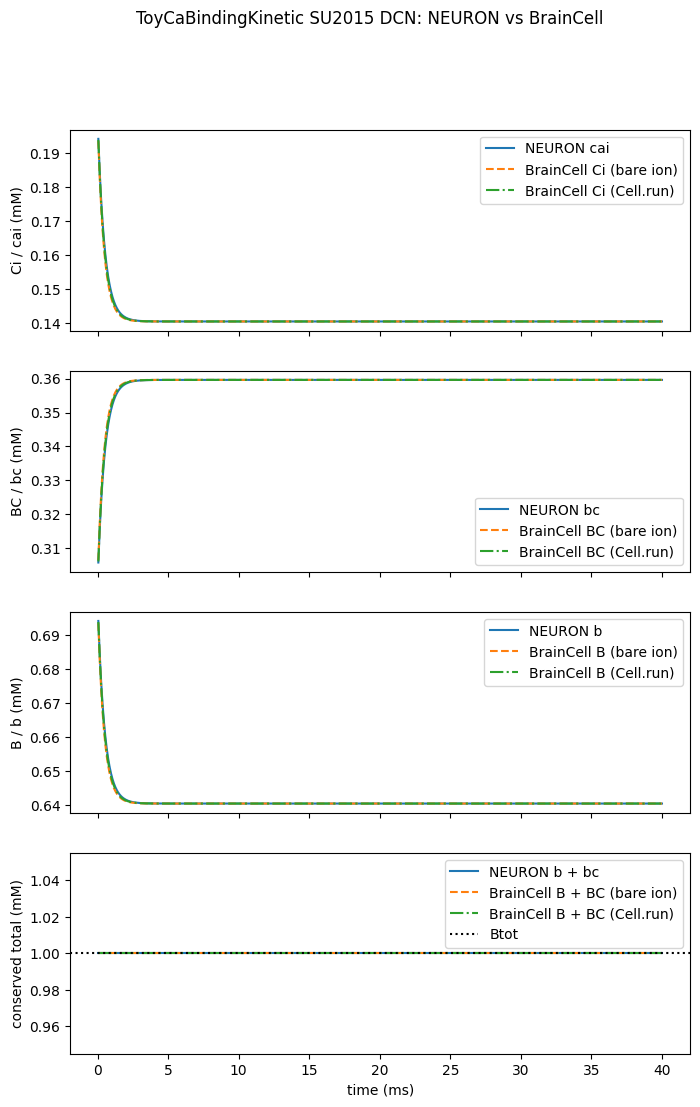

bare-ion Ci error: {'mae': 7.659619424663262e-05, 'rmse': 0.00035237962003473286, 'max_abs': 0.0023974898123590715}
bare-ion BC error: {'mae': 7.659619424652167e-05, 'rmse': 0.00035237962003472993, 'max_abs': 0.0023974898123592103}
bare-ion B error: {'mae': 7.659619424655594e-05, 'rmse': 0.0003523796200347287, 'max_abs': 0.0023974898123592103}
Cell.run Ci error: {'mae': 3.756478017258171e-05, 'rmse': 0.00017046263341552383, 'max_abs': 0.0011427173340927133}
Cell.run BC error: {'mae': 3.7564780172880185e-05, 'rmse': 0.0001704626334154646, 'max_abs': 0.0011427173340926022}
Cell.run B error: {'mae': 3.7564780172912596e-05, 'rmse': 0.00017046263341546344, 'max_abs': 0.0011427173340925467}


In [7]:
compare_t_ms = times_ms[1:]
neuron_cai_cmp = neuron_cai_mM[1:]
neuron_bc_cmp = neuron_bc_mM[1:]
neuron_b_cmp = neuron_b_mM[1:]
neuron_total_cmp = neuron_total_mM[1:]

bare_cai_cmp = bc_cai_mM[1:]
bare_bc_cmp = bc_bc_mM[1:]
bare_b_cmp = bc_b_mM[1:]
bare_total_cmp = bc_total_mM[1:]

cell_t_ms = compare_t_ms[:len(cell_cai_mM)]

def summarize_error(y, ref):
    y = np.asarray(y)
    ref = np.asarray(ref)
    n = min(len(y), len(ref))
    diff = y[:n] - ref[:n]
    return {
        'mae': float(np.mean(np.abs(diff))),
        'rmse': float(np.sqrt(np.mean(diff ** 2))),
        'max_abs': float(np.max(np.abs(diff))),
    }

err_bare_ci = summarize_error(bare_cai_cmp, neuron_cai_cmp)
err_bare_bc = summarize_error(bare_bc_cmp, neuron_bc_cmp)
err_bare_b = summarize_error(bare_b_cmp, neuron_b_cmp)
err_cell_ci = summarize_error(cell_cai_mM, neuron_cai_cmp[:len(cell_cai_mM)])
err_cell_bc = summarize_error(cell_bc_mM, neuron_bc_cmp[:len(cell_bc_mM)])
err_cell_b = summarize_error(cell_b_mM, neuron_b_cmp[:len(cell_b_mM)])

fig, axes = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

axes[0].plot(compare_t_ms, neuron_cai_cmp, label='NEURON cai')
axes[0].plot(compare_t_ms, bare_cai_cmp, '--', label='BrainCell Ci (bare ion)')
axes[0].plot(cell_t_ms, cell_cai_mM, '-.', label='BrainCell Ci (Cell.run)')
axes[0].set_ylabel('Ci / cai (mM)')
axes[0].legend()

axes[1].plot(compare_t_ms, neuron_bc_cmp, label='NEURON bc')
axes[1].plot(compare_t_ms, bare_bc_cmp, '--', label='BrainCell BC (bare ion)')
axes[1].plot(cell_t_ms, cell_bc_mM, '-.', label='BrainCell BC (Cell.run)')
axes[1].set_ylabel('BC / bc (mM)')
axes[1].legend()

axes[2].plot(compare_t_ms, neuron_b_cmp, label='NEURON b')
axes[2].plot(compare_t_ms, bare_b_cmp, '--', label='BrainCell B (bare ion)')
axes[2].plot(cell_t_ms, cell_b_mM, '-.', label='BrainCell B (Cell.run)')
axes[2].set_ylabel('B / b (mM)')
axes[2].legend()

axes[3].plot(compare_t_ms, neuron_total_cmp, label='NEURON b + bc')
axes[3].plot(compare_t_ms, bare_total_cmp, '--', label='BrainCell B + BC (bare ion)')
axes[3].plot(cell_t_ms, cell_total_mM, '-.', label='BrainCell B + BC (Cell.run)')
axes[3].axhline(btot_mM, color='k', linestyle=':', label='Btot')
axes[3].set_xlabel('time (ms)')
axes[3].set_ylabel('conserved total (mM)')
axes[3].legend()

plt.suptitle('ToyCaBindingKinetic SU2015 DCN: NEURON vs BrainCell')
plt.show()

print('bare-ion Ci error:', err_bare_ci)
print('bare-ion BC error:', err_bare_bc)
print('bare-ion B error:', err_bare_b)
print('Cell.run Ci error:', err_cell_ci)
print('Cell.run BC error:', err_cell_bc)
print('Cell.run B error:', err_cell_b)
